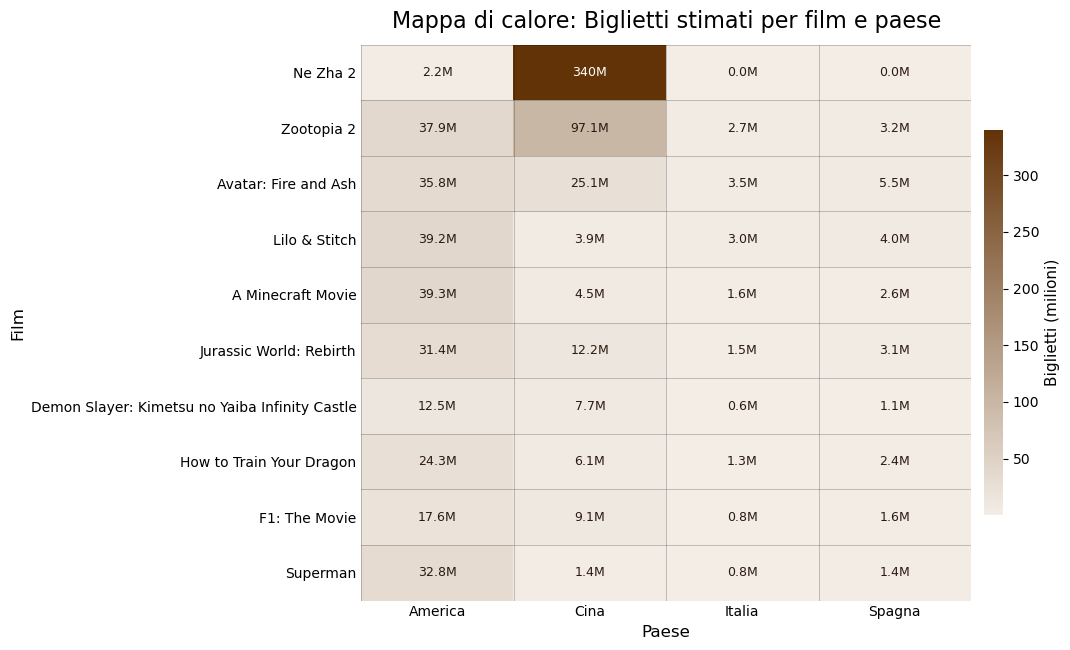

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from matplotlib.colors import LinearSegmentedColormap

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[€$]", "", s)
    s = s.replace(" ", "")
    s = re.sub(r"[^0-9,\.]", "", s)
    if s == "":
        return np.nan
    if "," in s and "." in s:
        s = s.replace(",", "")
    else:
        if s.count(".") >= 2 and "," not in s:
            s = s.replace(".", "")
        elif s.count(",") >= 2 and "." not in s:
            s = s.replace(",", "")
        else:
            if "," in s and "." not in s:
                s = s.replace(".", "").replace(",", ".")
            elif "." in s and "," not in s:
                parts = s.split(".")
                if len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                    s = "".join(parts)
    try:
        return float(s)
    except:
        return np.nan

def parse_eur_price(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["", "-", "nan", "none"]:
        return np.nan
    s = s.replace("€", "").replace("eur", "").strip()
    s = s.replace(",", ".")
    s = re.sub(r"[^0-9\.]", "", s)
    if s == "":
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

def norm_key(s):
    s = "" if s is None else str(s)
    s = s.strip().lower()
    s = s.replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+", " ", s)
    return s

raw = pd.read_csv("Nazione.csv")
raw.columns = raw.columns.str.strip()

header_row = raw.iloc[0].tolist()
new_cols = []
for i, c in enumerate(raw.columns):
    v = header_row[i]
    v = "" if pd.isna(v) else str(v).strip()
    new_cols.append(v if v != "" else str(c).strip())

incassi = raw.iloc[1:].copy()
incassi.columns = new_cols
incassi = incassi.loc[:, [c for c in incassi.columns if not str(c).lower().startswith("unnamed")]]

col_movie = incassi.columns[0]
incassi = incassi.rename(columns={col_movie: "Movie"})
incassi["Movie"] = incassi["Movie"].astype(str).str.strip()

for c in incassi.columns:
    if c != "Movie":
        incassi[c] = incassi[c].apply(parse_money)

prezzi = pd.read_csv("PrezzoMedioTickets.csv")
prezzi.columns = [str(c).strip() for c in prezzi.columns]
prezzi = prezzi.iloc[0].to_dict()
prezzi = {str(k).strip(): parse_eur_price(v) for k, v in prezzi.items()}

syn = {
    "china": "cina",
    "cina": "cina",
    "italy": "italia",
    "italia": "italia",
    "spain": "spagna",
    "spagna": "spagna",
    "america": "america",
    "united states": "america",
    "usa": "america",
    "u.s.a.": "america",
    "united kingdom": "regno unito",
    "uk": "regno unito",
    "regno unito": "regno unito",
    "germany": "germania",
    "germania": "germania",
    "japan": "giappone",
    "giappone": "giappone",
    "singapore": "singapore",
    "malaysia": "malesia",
    "malesia": "malesia",
}

inc_cols = [c for c in incassi.columns if c != "Movie"]
m_inc = {}
for c in inc_cols:
    k = norm_key(c)
    m_inc[k] = c
    if k in syn:
        m_inc[syn[k]] = c

m_pre = {}
for c in prezzi.keys():
    k = norm_key(c)
    m_pre[k] = c
    if k in syn:
        m_pre[syn[k]] = c

chiavi_comuni = sorted(list(set(m_inc.keys()).intersection(set(m_pre.keys()))))
chiavi_comuni = [k for k in chiavi_comuni if k not in ["", "none", "nan"]]

if len(chiavi_comuni) == 0:
    raise ValueError("Ancora nessuna nazione in comune: controlla i nomi delle nazioni tra Nazione.csv e PrezzoMedioTickets.csv.")

ordine_preferito = ["america", "cina", "regno unito", "italia", "spagna"]
chiavi_comuni = [k for k in ordine_preferito if k in chiavi_comuni] + [k for k in chiavi_comuni if k not in ordine_preferito]

cols_inc = ["Movie"] + [m_inc[k] for k in chiavi_comuni]
tmp = incassi[cols_inc].copy()

prices_vec = np.array([prezzi[m_pre[k]] for k in chiavi_comuni], dtype=float)
prices_vec = np.where(np.isfinite(prices_vec) & (prices_vec > 0), prices_vec, np.nan)

M = tmp.drop(columns=["Movie"]).to_numpy(dtype=float)
tickets = M / prices_vec
tickets = np.where(np.isfinite(tickets), tickets, np.nan)

movies = tmp["Movie"].astype(str).tolist()
labels_paesi = []
for k in chiavi_comuni:
    c = m_pre[k]
    labels_paesi.append(str(c).strip())

theme = "#633308"
light = "#f3ede6"
cmap = LinearSegmentedColormap.from_list("tema_marrone", [light, theme])

fig, ax = plt.subplots(figsize=(10.8, 6.6))
im = ax.imshow(tickets / 1e6, aspect="auto", cmap=cmap)

ax.set_title("Mappa di calore: Biglietti stimati per film e paese", fontsize=16, pad=12)
ax.set_xlabel("Paese", fontsize=12)
ax.set_ylabel("Film", fontsize=12)

ax.set_xticks(np.arange(len(labels_paesi)))
ax.set_xticklabels(labels_paesi, rotation=0)
ax.set_yticks(np.arange(len(movies)))
ax.set_yticklabels(movies)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(np.arange(-.5, len(labels_paesi), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(movies), 1), minor=True)
ax.grid(which="minor", color="#000000", linestyle="-", linewidth=0.6, alpha=0.25)
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(length=0)

vals = tickets / 1e6
vmax = np.nanmax(vals) if np.isfinite(np.nanmax(vals)) else 0
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v = vals[i, j]
        if np.isfinite(v) and v > 0:
            txt = f"{v:.1f}M" if v < 100 else f"{v:.0f}M"
            color_txt = "white" if (vmax > 0 and v / vmax > 0.55) else "#2b1a10"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, color=color_txt)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Biglietti (milioni)", fontsize=11)
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()